In [1]:
import matplotlib.pyplot as plt
import numpy as np

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import rasterio

BoundingBox(left=-60.64908001743606, bottom=34.98559499531334, right=14.014005920063937, top=76.07446218281333)


Text(-17.5, 56.9, 'L')

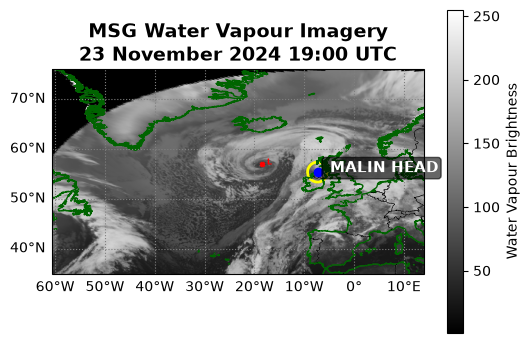

In [32]:
tif_file = "./data/week3/wmsMap_2024-11-23T1900.tif"
with rasterio.open(tif_file) as src:
    # Read the first band (Water Vapor channel)
    wv_band = src.read(1)
    # Get spatial extent for plotting: [left, right, bottom, top]
    bounds = src.bounds
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    # Retrieve coordinate reference system if needed (typically EPSG:4326 for geostationary lat/lon grids)
    crs = src.crs
    print(bounds)

dublin_airport_lat = 55.372
dublin_airport_lon = -7.339


fig, ax = plt.subplots(
    figsize=(6, 6), subplot_kw={"projection": ccrs.PlateCarree()}
)

# Set spatial extent
# Extent format: [min_lon, max_lon, min_lat, max_lat]
ax.set_extent(
    [-60.649, 14.014, 34.986, 76.074],
    crs=ccrs.PlateCarree()
)
# Display the satellite image as background
# Water Vapor channel is typically displayed inverted or in grayscale ('gray' or 'gray_r')
im = ax.imshow(
    wv_band,
    origin="upper",
    extent=extent,
    cmap="gray",
    transform=ccrs.PlateCarree(),
    vmin=1,
    vmax=255,
)

# Overlay Cartopy Features (Coastline & Borders)
ax.add_feature(
    cfeature.COASTLINE.with_scale("10m"), edgecolor="darkgreen", linewidth=1
)

# 6. Plot Dublin Airport location
ax.plot(
    dublin_airport_lon,
    dublin_airport_lat,
    'bo',
    transform=ccrs.PlateCarree()
)

# Add text label next to the marker
ax.text(
    dublin_airport_lon + 1.5,
    dublin_airport_lat,
    " MALIN HEAD",
    color="white",
    fontsize=11,
    fontweight="bold",
    transform=ccrs.PlateCarree(),
    bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.6),
)

# Add Gridlines, Labels, Colorbar & Title
gl = ax.gridlines(
    draw_labels=True, crs=ccrs.PlateCarree(), linestyle=":", color="gray"
)
gl.top_labels = False
gl.right_labels = False
ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.5,
    edgecolor="black"
)
cbar = plt.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label("Water Vapour Brightness")

import matplotlib.patches as mpatches

circle = mpatches.Circle(
    (-7.339, 55.372),
    radius=2,
    fill=False,
    edgecolor="yellow",
    linewidth=2,
    transform=ccrs.PlateCarree()
)

ax.add_patch(circle)
ax.set_title(
    "MSG Water Vapour Imagery\n23 November 2024 19:00 UTC",
    fontsize=14,
    weight='bold'
)
 

min_pixel = np.unravel_index(
    np.argmin(wv_band),
    wv_band.shape
)

cyclone_lon = -18.5
cyclone_lat = 56.9


ax.plot(
    cyclone_lon,
    cyclone_lat,
    marker='x',
    color='red',
    markersize=3,
    mew=2,
    transform=ccrs.PlateCarree()
)

ax.text(
    cyclone_lon + 1,
    cyclone_lat,
    "L",
    color="red",
    fontsize=6,
    fontweight="bold",
    transform=ccrs.PlateCarree()
)